In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.shape

(100, 4)

In [5]:
#steps 
#0. preprocess + EDA + feature selection
#1. extract i\o columns
#2. scale the values
#3. train test split
#4. train the model
#5. evalutate model /model selection
#6. deploy model

In [6]:
# remove the unamed col thats is empty
df = df.iloc[:, 1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
#for eda
import matplotlib.pyplot as plt

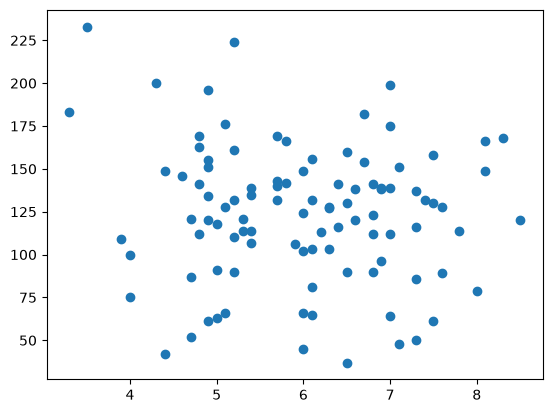

In [9]:
plt.scatter(df['cgpa'],df['iq'])

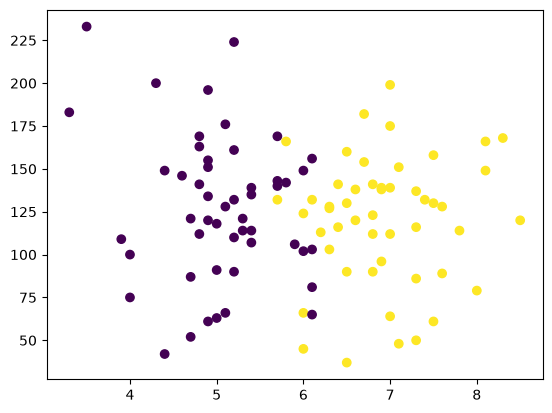

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement']) # yellow=> placed

In [11]:
#eda => gives idea logistic regression data liner 
#cg id independent and placement dependent
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [12]:
X.shape

(100, 2)

In [13]:
#for training 
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [14]:
X_train

,cgpa,iq
36,5.7,140.0
66,6.9,96.0
9,5.1,66.0
12,5.4,139.0
17,3.3,183.0
...,...,...
96,4.4,42.0
50,3.5,233.0
51,4.8,141.0
44,7.5,61.0


In [15]:
Y_train

36    0
66    1
9     0
12    0
17    0
     ..
96    0
50    0
51    0
44    1
25    0
Name: placement, Length: 90, dtype: int64

In [16]:
#scaling
from sklearn.preprocessing import StandardScaler

In [17]:
scaler=StandardScaler()

In [18]:
X_train=scaler.fit_transform(X_train)

In [19]:
X_train #df => array

array([[-0.28803933,  0.38479772],
       [ 0.77367561, -0.68981368],
       [-0.8188968 , -1.42250327],
       [-0.55346806,  0.36037473],
       [-2.4114692 ,  1.43498612],
       [-0.73042055,  0.89768043],
       [ 0.41977063, -0.8363516 ],
       [-0.99584929, -0.10366201],
       [ 0.59672312,  1.41056314],
       [-0.64194431, -0.07923902],
       [ 0.24281814,  0.09172188],
       [ 0.06586565, -1.44692625],
       [ 0.50824687, -0.10366201],
       [-0.11108684, -0.44558382],
       [-1.08432553,  1.09306432],
       [ 0.95062809, -1.86211702],
       [-0.8188968 ,  0.09172188],
       [ 0.41977063,  0.87325744],
       [ 0.50824687,  0.33595174],
       [ 0.24281814, -0.51885277],
       [-0.99584929,  1.75248495],
       [-0.99584929,  0.75114251],
       [-0.55346806,  0.26268279],
       [ 0.59672312,  0.72671952],
       [ 0.86215185,  0.36037473],
       [-0.28803933,  0.18941383],
       [ 0.33129438, -0.20135395],
       [ 1.12758058, -0.20135395],
       [ 1.30453307,

In [20]:
X_test=scaler.transform(X_test)

In [21]:
X_test

array([[ 0.33129438,  0.4092207 ],
       [ 0.68519936, -0.8363516 ],
       [-0.99584929,  0.65345057],
       [-1.17280178, -0.90962055],
       [-0.73042055, -0.34789187],
       [ 1.7469143 , -1.10500444],
       [-1.17280178, -0.07923902],
       [ 0.06586565,  0.7755655 ],
       [-1.88061173, -0.37231486],
       [ 0.06586565,  0.18941383]])

In [22]:
# now lets train model we decided logistic regression 

In [23]:

from sklearn.linear_model import LogisticRegression

In [24]:
clf=LogisticRegression()

In [25]:
clf.fit(X_train,Y_train)  #model training

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [26]:
Y_pred=clf.predict(X_test)

In [27]:
Y_test

54    1
35    1
89    0
23    0
92    0
58    1
24    0
8     0
31    0
71    1
Name: placement, dtype: int64

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(Y_test,Y_pred)

0.9

In [30]:
#how to plot decision boundary
from mlxtend.plotting import plot_decision_regions

<Axes: >

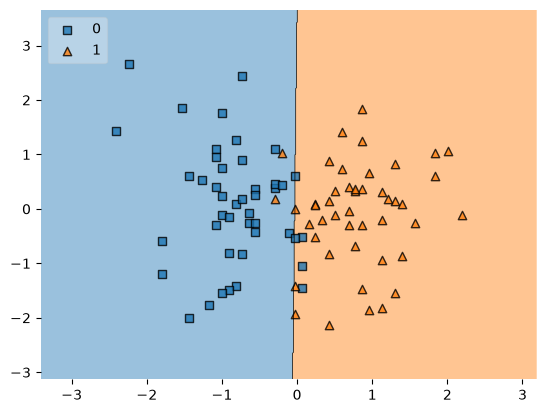

In [31]:
plot_decision_regions(X_train,Y_train.values,clf=clf,legend=2)

In [32]:
 import pickle  # object => file convert


In [33]:
pickle.dump(clf,open('model.pkl','wb'))